# 03 — CNN-1D para Clasificación de Texto

**Modelo:** Red Neuronal Convolucional 1D con embeddings entrenables  
**Input:** secuencias paddeadas (`X_train/val/test.npy`) + etiquetas (`y_*.npy`)  
**Output:** categoría profesional (24 clases)  
**Entorno:** Python 3.10 · TensorFlow 2.20.0 · GPU (CUDA)

## 1. Imports y configuración

In [16]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Rutas ──────────────────────────────────────────────────────────────────
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
METRICS_DIR   = os.path.join(ARTIFACTS_DIR, 'metrics')
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga de artefactos

In [17]:
# ── Secuencias paddeadas ────────────────────────────────────────────────────
X_train = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(ARTIFACTS_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy'))

y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

# ── Config y LabelEncoder ──────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

MAX_LEN     = config['MAX_LEN']
VOCAB_SIZE  = config['VOCAB_SIZE']
NUM_CLASSES = config['NUM_CLASSES']
CLASS_NAMES = le.classes_

print(f'MAX_LEN={MAX_LEN}  VOCAB_SIZE={VOCAB_SIZE}  NUM_CLASSES={NUM_CLASSES}')
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

MAX_LEN=100  VOCAB_SIZE=20000  NUM_CLASSES=24
Train: (1738, 100)  Val: (373, 100)  Test: (373, 100)


## 3. Pesos de clase (manejo del desbalance)

In [18]:
from sklearn.utils import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

print('Pesos de clase (min / max):', 
      f"{min(class_weights_arr):.3f} / {max(class_weights_arr):.3f}")

Pesos de clase (min / max): 0.862 / 4.828


## 4. Arquitectura CNN-1D

In [19]:
# ── Hiperparámetros ─────────────────────────────────────────────────────────
EMBEDDING_DIM = 128
NUM_FILTERS   = 128
KERNEL_SIZE   = 5
DROPOUT_RATE  = 0.4
LEARNING_RATE = 0.001
BATCH_SIZE    = 64
EPOCHS        = 50   # early stopping controla la parada real

# ── Modelo ──────────────────────────────────────────────────────────────────
inputs = keras.Input(shape=(MAX_LEN,), name='input_seq')

x = layers.Embedding(
    input_dim=VOCAB_SIZE + 1,   # +1 por el token 0 (padding)
    output_dim=EMBEDDING_DIM,
    mask_zero=False,
    name='embedding'
)(inputs)

x = layers.Conv1D(
    filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    activation='relu',
    padding='same',
    name='conv1d'
)(x)

x = layers.GlobalMaxPooling1D(name='global_max_pool')(x)

x = layers.Dense(128, activation='relu', name='dense_1')(x)
x = layers.Dropout(DROPOUT_RATE, name='dropout')(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = keras.Model(inputs, outputs, name='CNN1D_text_classifier')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "CNN1D_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,661,784 (10.15 MB)

 Trainable params: 2,661,784 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

In [20]:
MODEL_PATH = os.path.join(MODELS_DIR, 'cnn1d.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f'\nEntrenamiento finalizado — mejor modelo guardado en: {MODEL_PATH}')

Epoch 1/50


2026-05-16 10:39:51.061422: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-16 10:39:51.061640: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-16 10:39:51.061706: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-16 10:39:53.517105: I external/l

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.0403 - loss: 3.1558

2026-05-16 10:40:03.584261: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-16 10:40:03.878968: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_46', 8 bytes spill stores, 8 bytes spill loads

2026-05-16 10:40:04.112584: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_46', 28 bytes spill stores, 28 bytes spill loads

2026-05-16 10:40:04.221848: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_46', 36 bytes spil


Epoch 1: val_loss improved from None to 3.16194, saving model to /home/alejo/DeepLearning/miniproyecto3/models/cnn1d.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 294ms/step - accuracy: 0.0460 - loss: 3.1816 - val_accuracy: 0.1475 - val_loss: 3.1619 - learning_rate: 0.0010
Epoch 2/50
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2130 - loss: 3.0855
Epoch 2: val_loss improved from 3.16194 to 3.11864, saving model to /home/alejo/DeepLearning/miniproyecto3/models/cnn1d.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2146 - loss: 3.1114 - val_accuracy: 0.3217 - val_loss: 3.1186 - learning_rate: 0.0010
Epoch 3/50
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3988 - loss: 2.9702
Epoch 3: val_loss improved from 3.11864 to 2.88117, saving model to /home/alejo/DeepLearning/miniproyecto3/models/cnn1d.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3878 - loss: 2.9602 - val_accuracy: 0.3914 - val_loss: 2.8812 - learning_rate: 0.0010
Epoch 4/50
25/28 ━━━━━━━━━━━━━━━━━

## 6. Curvas de entrenamiento

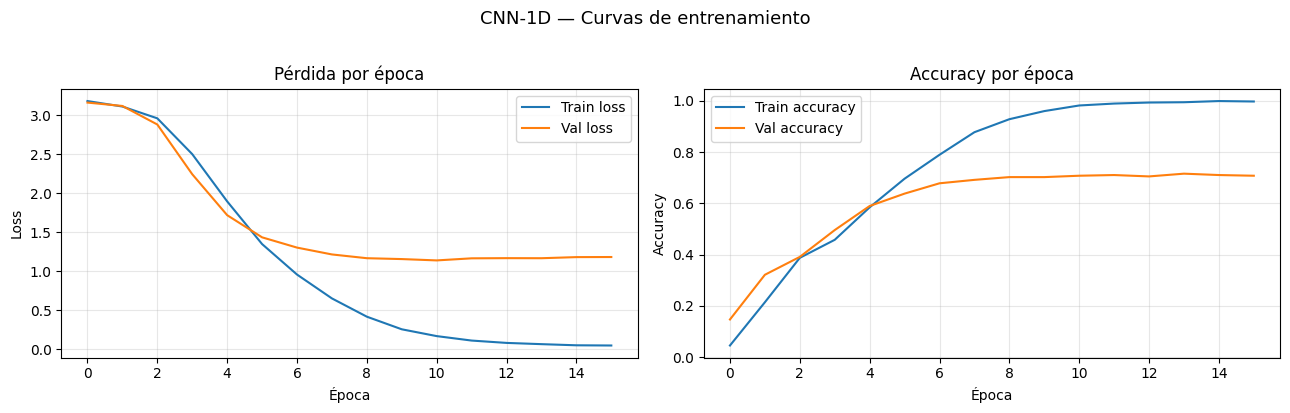

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN-1D — Curvas de entrenamiento', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Evaluación en test

In [22]:
# ── Predicciones ────────────────────────────────────────────────────────────
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)  # (n, 24)
y_pred = np.argmax(y_prob, axis=1)

# ── Métricas escalares ──────────────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

# ROC-AUC multiclase OvR
y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
roc_auc    = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')

print('=' * 50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {precision:.4f}  (weighted)')
print(f'  Recall    : {recall:.4f}  (weighted)')
print(f'  F1-score  : {f1:.4f}  (weighted)')
print(f'  ROC-AUC   : {roc_auc:.4f}  (OvR weighted)')
print('=' * 50)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

  Accuracy  : 0.7265
  Precision : 0.7091  (weighted)
  Recall    : 0.7265  (weighted)
  F1-score  : 0.7067  (weighted)
  ROC-AUC   : 0.9524  (OvR weighted)

Classification report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.81      1.00      0.89        17
              ADVOCATE       0.94      0.88      0.91        17
           AGRICULTURE       0.50      0.20      0.29        10
               APPAREL       0.20      0.14      0.17        14
                  ARTS       0.43      0.19      0.26        16
            AUTOMOBILE       1.00      0.40      0.57         5
              AVIATION       0.79      0.61      0.69        18
               BANKING       0.67      0.56      0.61        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.78      1.00      0.88        18
                  CHEF       1.00      0.82      0.90        17
          CONSTRUCTION       0.94      1.00      0

## 8. Matriz de confusión

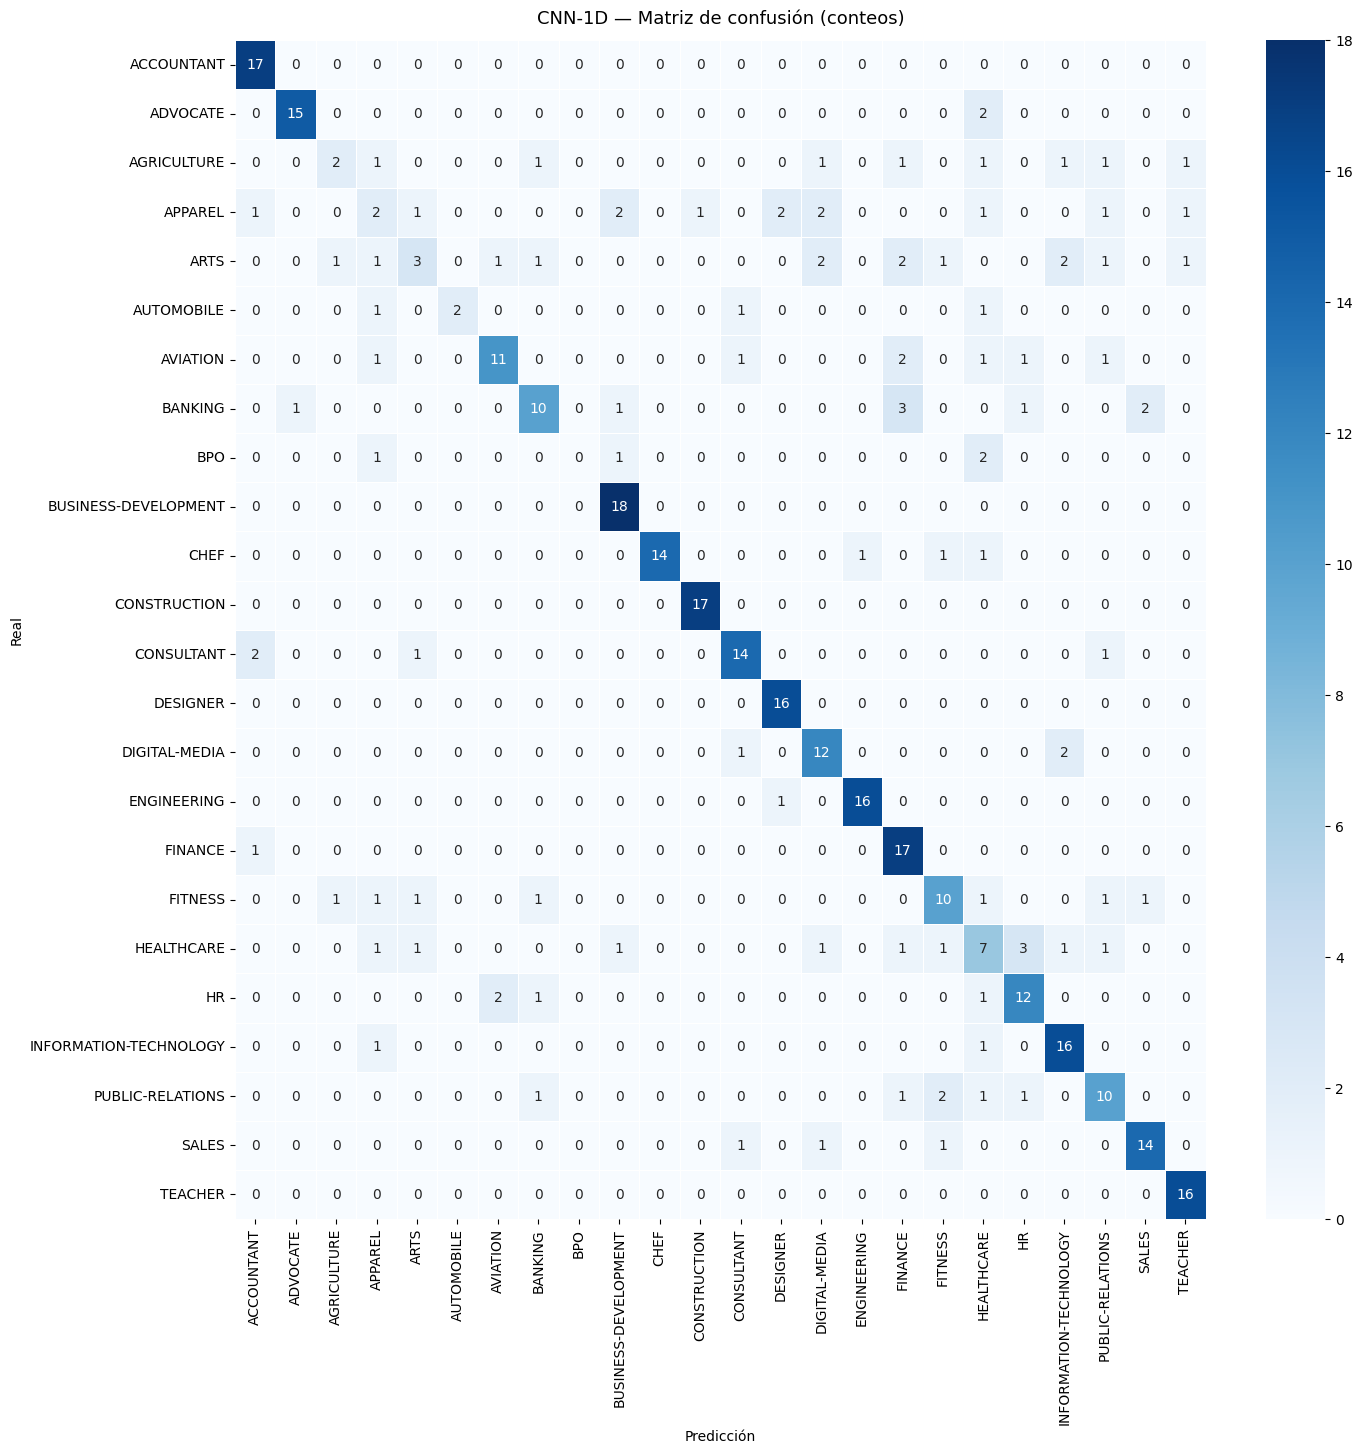

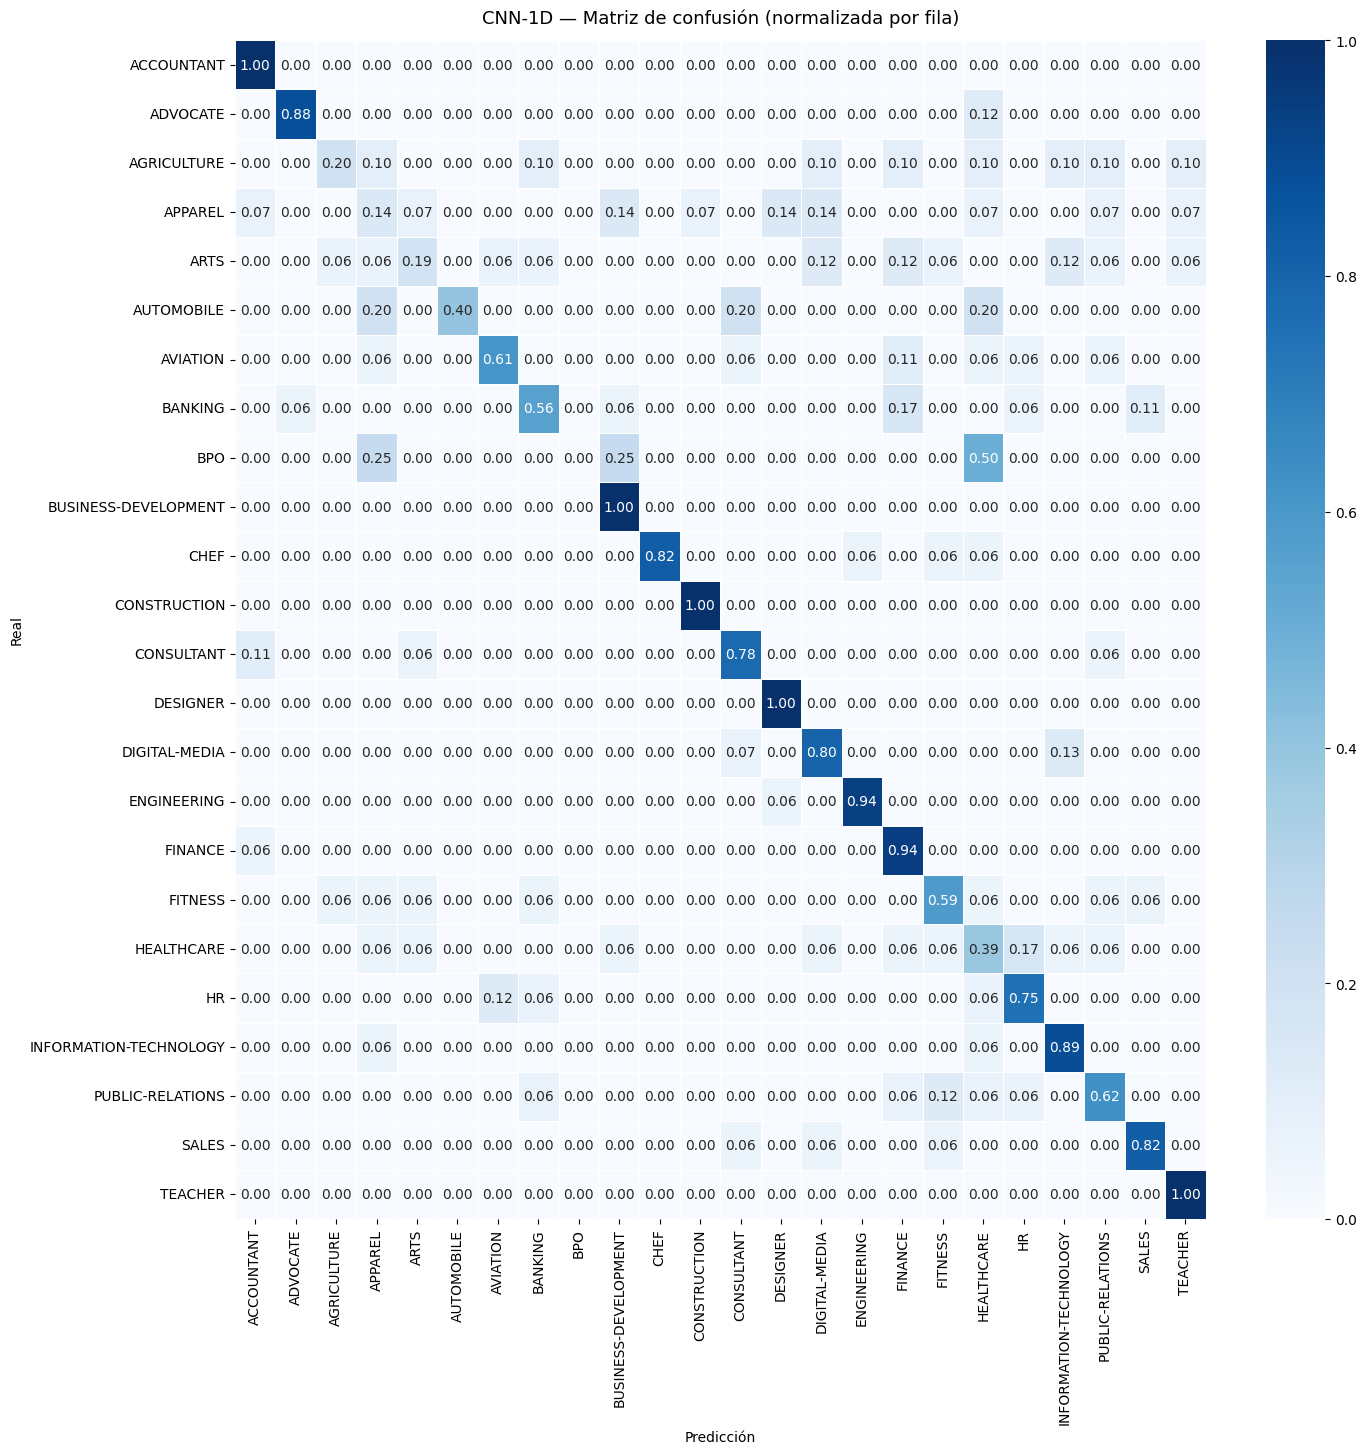

In [23]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

n       = NUM_CLASSES
cell_px = 52
fig_sz  = max(10, n * cell_px / 72)

# ── Absoluta ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.4, cbar=True
)
ax.set_title('CNN-1D — Matriz de confusión (conteos)', fontsize=13, pad=12)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.2, left=0.2)
plt.show()

# ── Normalizada ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.4, vmin=0, vmax=1, cbar=True
)
ax.set_title('CNN-1D — Matriz de confusión (normalizada por fila)', fontsize=13, pad=12)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.2, left=0.2)
plt.show()

## 9. Curva ROC (OvR — macro)

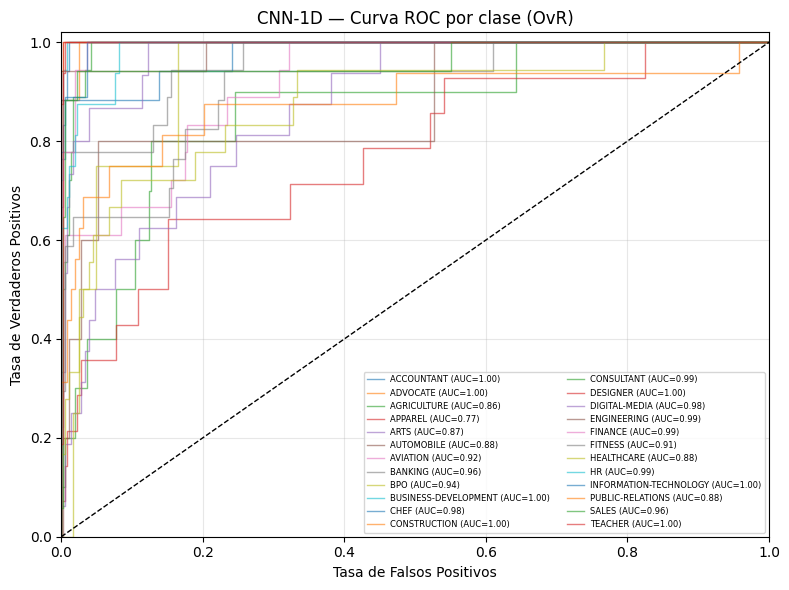

In [24]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for i, cls_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1, alpha=0.6, label=f'{cls_name} (AUC={roc_auc_i:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('CNN-1D — Curva ROC por clase (OvR)')
ax.legend(loc='lower right', fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Curva Precision-Recall

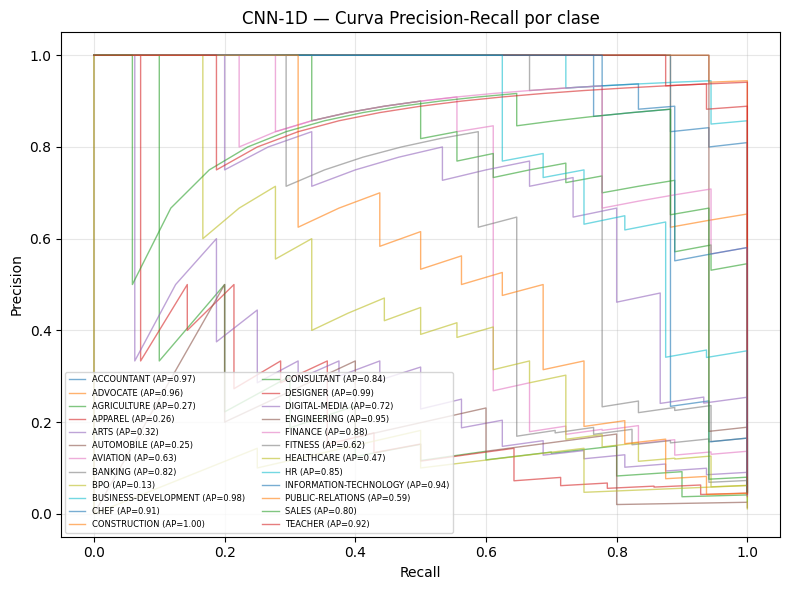

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for i, cls_name in enumerate(CLASS_NAMES):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap_i         = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(rec, prec, lw=1, alpha=0.6, label=f'{cls_name} (AP={ap_i:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('CNN-1D — Curva Precision-Recall por clase')
ax.legend(loc='lower left', fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Guardado de métricas

In [26]:
metrics = {
    'model'    : 'CNN-1D',
    'accuracy' : round(float(acc),       4),
    'precision': round(float(precision), 4),
    'recall'   : round(float(recall),    4),
    'f1'       : round(float(f1),        4),
    'roc_auc'  : round(float(roc_auc),   4),
    'hyperparams': {
        'embedding_dim': EMBEDDING_DIM,
        'num_filters'  : NUM_FILTERS,
        'kernel_size'  : KERNEL_SIZE,
        'dropout_rate' : DROPOUT_RATE,
        'learning_rate': LEARNING_RATE,
        'batch_size'   : BATCH_SIZE,
        'epochs_run'   : len(history.history['loss']),
    }
}

metrics_path = os.path.join(METRICS_DIR, 'cnn1d_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print('Métricas guardadas en:', metrics_path)
print(json.dumps(metrics, indent=2))

Métricas guardadas en: /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics/cnn1d_metrics.json
{
  "model": "CNN-1D",
  "accuracy": 0.7265,
  "precision": 0.7091,
  "recall": 0.7265,
  "f1": 0.7067,
  "roc_auc": 0.9524,
  "hyperparams": {
    "embedding_dim": 128,
    "num_filters": 128,
    "kernel_size": 5,
    "dropout_rate": 0.4,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs_run": 16
  }
}


## 12. Análisis crítico

**Arquitectura:** CNN-1D simple — Embedding entrenable → Conv1D (ReLU) → GlobalMaxPooling → Dense → Softmax. La capa convolucional actúa como detector de n-gramas locales; GlobalMaxPooling retiene el patrón más activado por cada filtro independientemente de su posición en la secuencia.

**Ventajas sobre TF-IDF + XGBoost:**
- Los embeddings aprenden representaciones semánticas densas (128 dims) en lugar de features dispersas de alta dimensión.
- Captura relaciones de orden local entre tokens (n-gramas implícitos vía kernels).
- Entrenamiento end-to-end: representación y clasificación se optimizan juntas.

**Limitaciones:**
- Con `MAX_LEN=100`, solo ve el ~10% del texto real (P95=1008 palabras). Los CVs son documentos largos — la truncación es una pérdida significativa de información.
- No captura dependencias de largo alcance (dominio de las arquitecturas recurrentes y transformers).
- Con 1738 muestras de entrenamiento y 24 clases, el embedding es pequeño — un modelo preentrenado (FastText, Word2Vec) aportaría más señal semántica.

**Desbalance:** Los pesos de clase balanceados compensan el ratio 5.45x. Se usan métricas weighted para una evaluación justa entre clases mayoritarias y minoritarias.